In [442]:
import numpy as np
import pandas as pd

In [443]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1.Knowing our Dataset**

In [444]:
df=pd.read_csv("/content/drive/MyDrive/Labmentix_All_Projects/Shopper_Spectrum_Project/Dataset/online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [445]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
422915,573123,23494,VINTAGE DOILY DELUXE SEWING KIT,3,2023-10-27 16:23:00,5.95,13654.0,United Kingdom
420322,572886,46000S,POLYESTER FILLER PAD 40x40cm,5,2023-10-26 13:46:00,1.45,12448.0,Spain
39697,539660,22620,4 TRADITIONAL SPINNING TOPS,2,2022-12-21 09:48:00,1.25,15581.0,United Kingdom
295680,562807,22355,CHARLOTTE BAG SUKI DESIGN,10,2023-08-09 14:57:00,0.85,16053.0,United Kingdom
122546,546884,22094,RED RETROSPOT TISSUE BOX,8,2023-03-17 18:08:00,2.46,NaN,United Kingdom


In [446]:
df.shape

(541909, 8)

In [447]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [448]:
df.duplicated().sum()


np.int64(5268)

In [449]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [450]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# **2.Data Preprocessing**

In [451]:
df_clean = df.copy()

In [452]:
df_clean.dropna(inplace=True)

In [453]:
df_clean.shape

(406829, 8)

In [454]:
df_clean[df_clean['InvoiceNo'].astype(str).str.startswith('C')].shape

(8905, 8)

In [455]:
df_clean=df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

In [456]:
df_clean.shape

(397924, 8)

In [457]:
df_clean[~df_clean['Quantity'] > 0].shape

(0, 8)

In [458]:
df_clean[df_clean['Quantity'] > 0].shape

(397924, 8)

In [459]:
df_clean = df_clean[df_clean['Quantity'] > 0]

In [460]:
df_clean.shape

(397924, 8)

In [461]:
df_clean.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [462]:
df_clean[df_clean['UnitPrice'] < 0].shape

(0, 8)

In [463]:
df_clean[df_clean['UnitPrice'] > 0].shape

(397884, 8)

In [464]:
df_clean[df_clean['UnitPrice'] == 0].shape

(40, 8)

In [465]:
df_clean.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [466]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [467]:
df_clean.shape

(397884, 8)

In [468]:
df_clean.describe()

,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453
std,179.331775,22.097877,1713.141560
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [469]:
df.duplicated().sum()

np.int64(5268)

In [470]:
df_clean = df_clean.drop_duplicates()

In [471]:
df_clean.shape

(392692, 8)

In [472]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [473]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [474]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [475]:
df_clean.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0


In [476]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2023-07-10 19:13:07.771892224,3.125914,15287.843865,22.631500
min,1.000000,2022-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2023-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2023-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2023-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2023-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [477]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


# **3.EDA**

In [478]:
import matplotlib.pyplot as plt
import seaborn as sns

In [479]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### **1)UNIVARIATE**

In [480]:
df_clean['InvoiceNo'].value_counts()

,count
InvoiceNo,
576339,542
579196,533
580727,529
578270,442
573576,435
...,...
551888,1
536400,1
536405,1


In [481]:
df_clean['InvoiceNo'].value_counts().head(15)

,count
InvoiceNo,
576339,542
579196,533
580727,529
578270,442
573576,435
567656,421
567183,392
575607,377
571441,364


In [482]:
df_clean['StockCode'].value_counts().head(15)

,count
StockCode,
85123A,2023
22423,1713
85099B,1615
84879,1395
47566,1389
20725,1304
22720,1152
POST,1099
23203,1091


In [483]:
df_clean['Quantity'].value_counts()

,count
Quantity,
1,69592
12,59826
2,57421
6,37480
4,32090
...,...
59,1
388,1
1404,1


In [484]:
df_clean['InvoiceDate'].value_counts()

,count
InvoiceDate,
2023-11-14 15:27:00,542
2023-11-28 15:54:00,533
2023-12-05 17:17:00,529
2023-11-23 13:39:00,443
2023-10-31 14:09:00,435
...,...
2023-12-08 18:45:00,1
2022-12-01 08:35:00,1
2022-12-01 09:00:00,1


In [485]:
df_clean['UnitPrice'].value_counts()

,count
UnitPrice,
1.25,45102
1.65,36286
2.95,26151
0.85,25658
0.42,21557
...,...
3.13,1
1.71,1
1.86,1


In [486]:
df_clean['CustomerID'].value_counts()

,count
CustomerID,
17841.0,7676
14911.0,5670
14096.0,5111
12748.0,4412
14606.0,2677
...,...
15070.0,1
17102.0,1
17763.0,1


In [487]:
df_clean['Country'].value_counts()

,count
Country,
United Kingdom,349203
Germany,9025
France,8326
EIRE,7226
Spain,2479
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1453


<Axes: xlabel='count', ylabel='Country'>

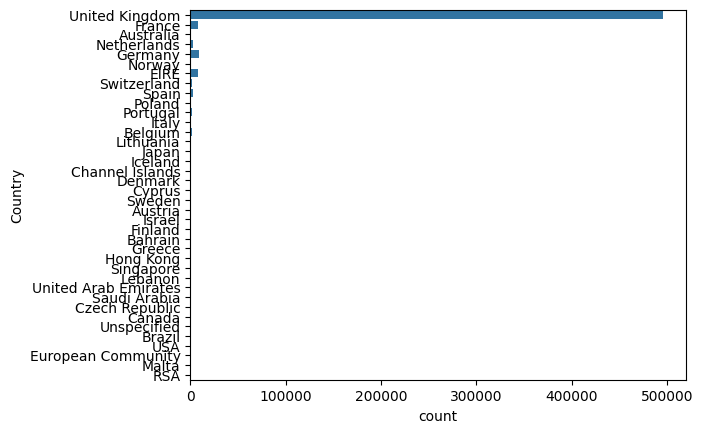

In [488]:
sns.countplot(df['Country'])

**2)Bi Variate**

In [489]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [490]:
country_transactions = (
    df_clean.groupby('Country')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

country_transactions.head(10)


,InvoiceNo
Country,
United Kingdom,16646
Germany,457
France,389
EIRE,260
Belgium,98
Netherlands,94
Spain,90
Portugal,57
Australia,57


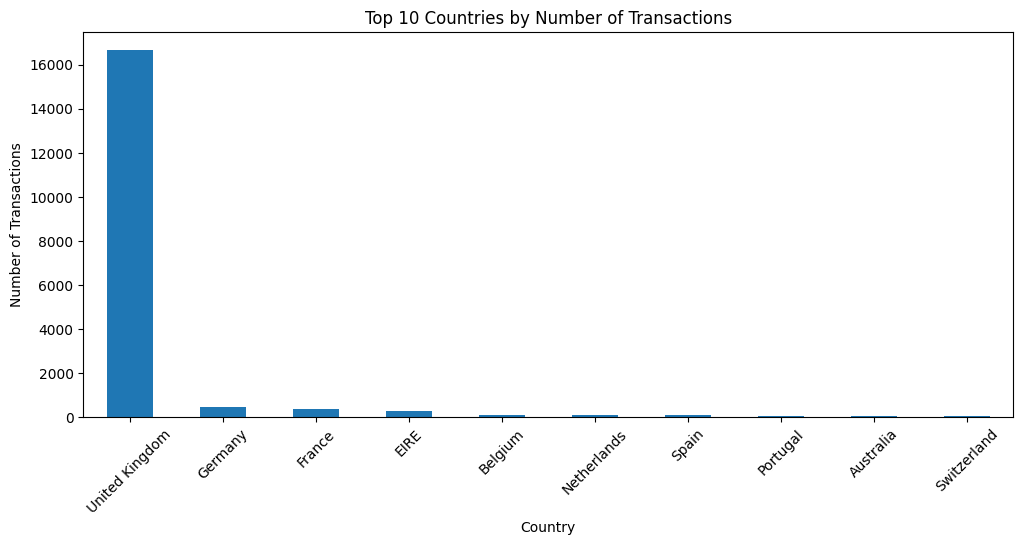

In [491]:
plt.figure(figsize=(12,5))
country_transactions.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()


In [492]:
country_revenue = (
    df_clean.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)


,TotalPrice
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


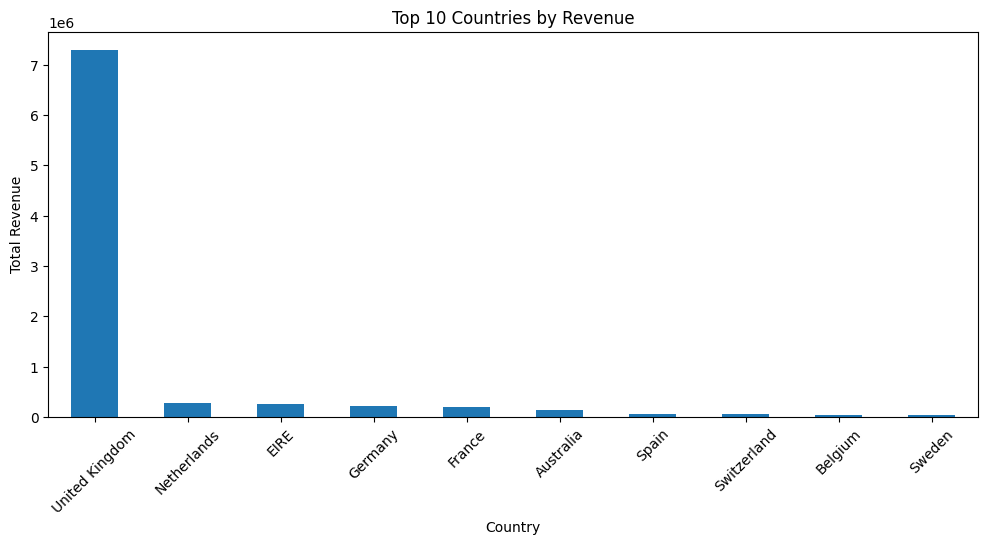

In [493]:
plt.figure(figsize=(12,5))
country_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


In [494]:
top_products_qty = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_qty


,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


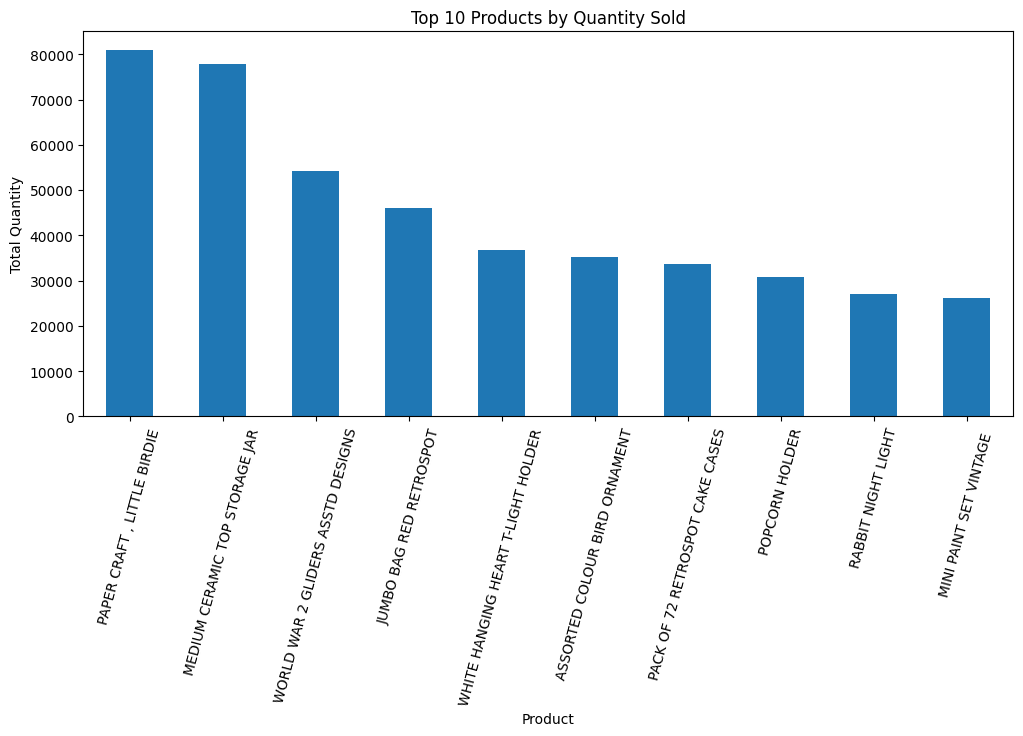

In [495]:
plt.figure(figsize=(12,5))
top_products_qty.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Total Quantity")
plt.xticks(rotation=75)
plt.show()


In [496]:
top_products_revenue = (
    df_clean.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue


,TotalPrice
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


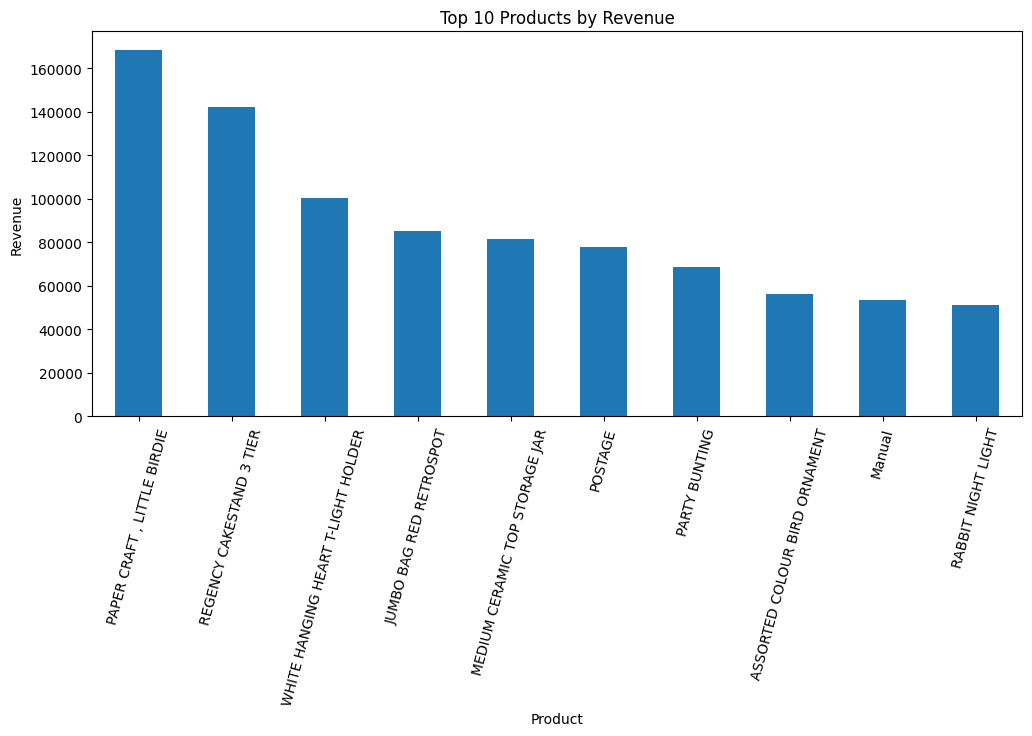

In [497]:
plt.figure(figsize=(12,5))
top_products_revenue.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.show()


In [498]:
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df_clean.groupby('InvoiceMonth')['TotalPrice']
    .sum()
)

monthly_sales


,TotalPrice
InvoiceMonth,
2022-12,570422.730
2023-01,568101.310
2023-02,446084.920
2023-03,594081.760
2023-04,468374.331
2023-05,677355.150
2023-06,660046.050
2023-07,598962.901
2023-08,644051.040


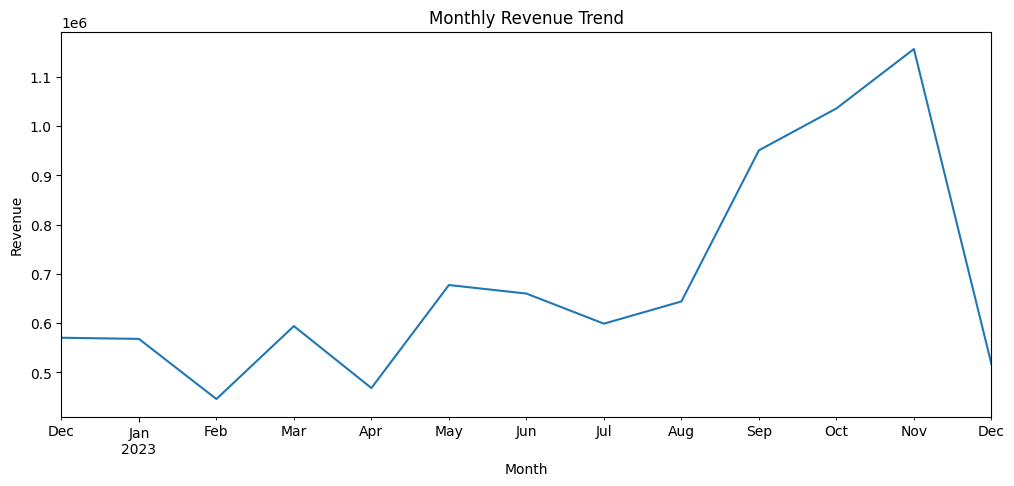

In [499]:
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


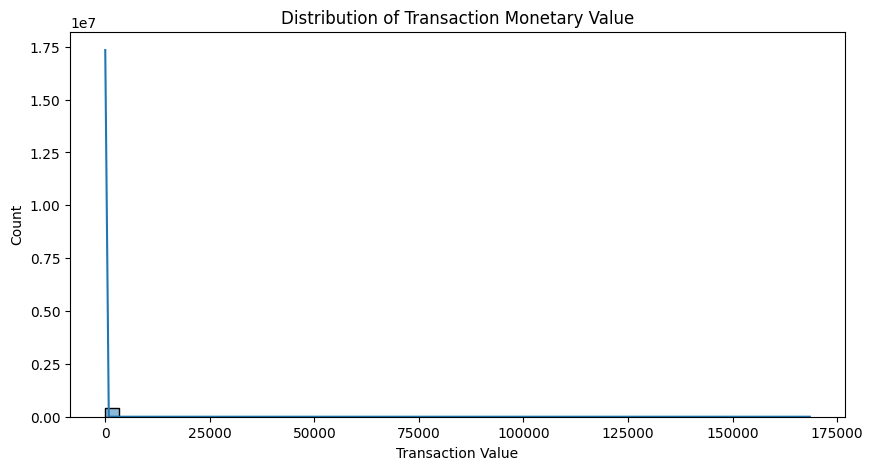

In [500]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['TotalPrice'], bins=50, kde=True)
plt.title("Distribution of Transaction Monetary Value")
plt.xlabel("Transaction Value")
plt.show()


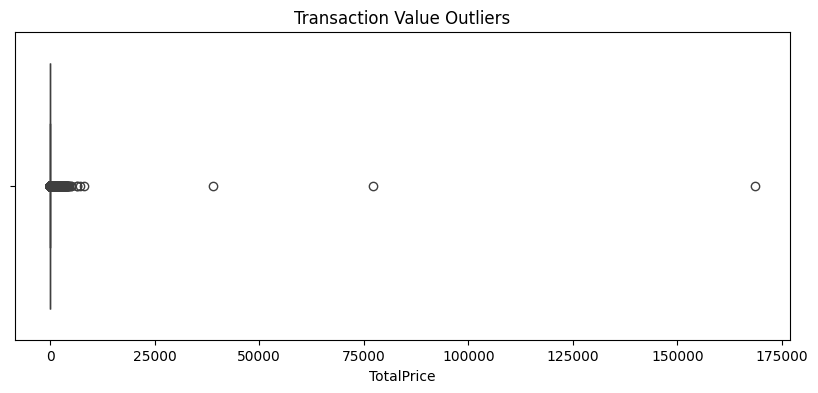

In [501]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_clean['TotalPrice'])
plt.title("Transaction Value Outliers")
plt.show()


In [502]:
customer_monetary = (
    df_clean.groupby('CustomerID')['TotalPrice']
    .sum()
)


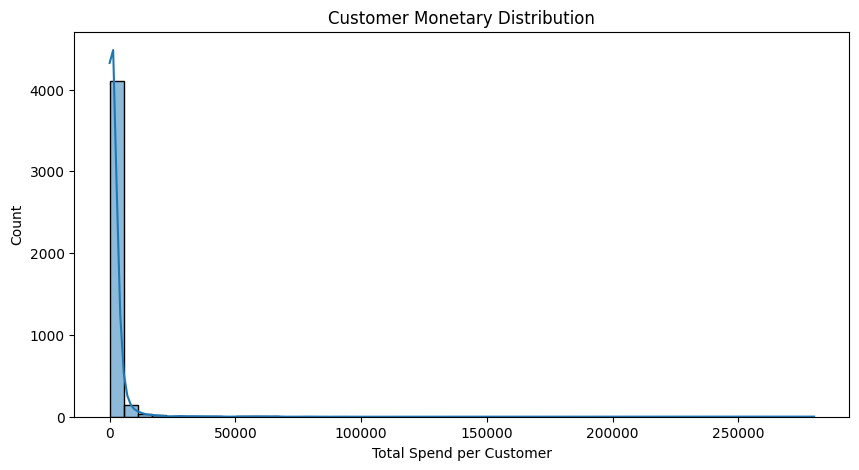

In [503]:
plt.figure(figsize=(10,5))
sns.histplot(customer_monetary, bins=50, kde=True)
plt.title("Customer Monetary Distribution")
plt.xlabel("Total Spend per Customer")
plt.show()


In [504]:
df_clean[['CustomerID','InvoiceDate','InvoiceNo','TotalPrice']].head()

,CustomerID,InvoiceDate,InvoiceNo,TotalPrice
0,17850.0,2022-12-01 08:26:00,536365,15.30
1,17850.0,2022-12-01 08:26:00,536365,20.34
2,17850.0,2022-12-01 08:26:00,536365,22.00
3,17850.0,2022-12-01 08:26:00,536365,20.34
4,17850.0,2022-12-01 08:26:00,536365,20.34


# **4.Feature Engineering**

In [505]:
df_clean['InvoiceDate'].max()

Timestamp('2023-12-09 12:50:00')

In [506]:
# Define reference date (latest invoice date + 1 day)
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date


Timestamp('2023-12-10 12:50:00')

In [507]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2022-12
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2022-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022-12


In [508]:
rfm = (
    df_clean.groupby('CustomerID')
    .agg({
        'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
        'InvoiceNo': 'nunique',                                     # Frequency
        'TotalPrice': 'sum'                                         # Monetary
    })
    .reset_index()
)

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [509]:
rfm.describe()


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


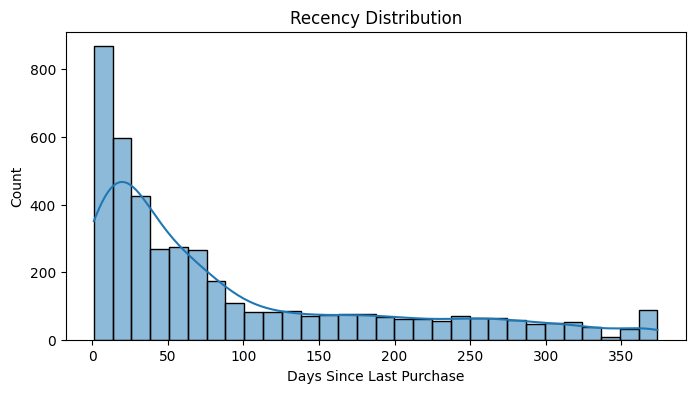

In [510]:
plt.figure(figsize=(8,4))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.show()


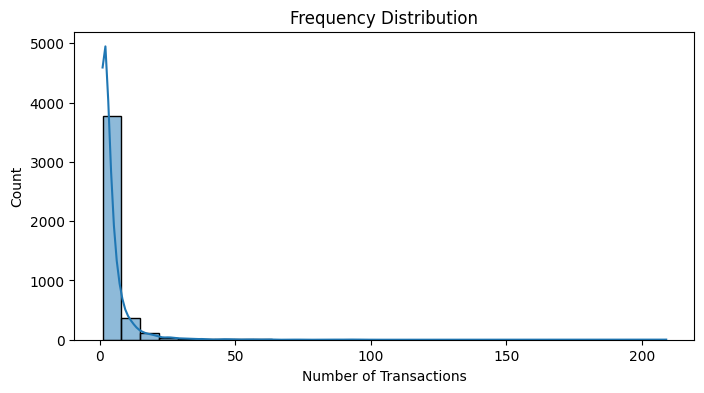

In [511]:
plt.figure(figsize=(8,4))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title("Frequency Distribution")
plt.xlabel("Number of Transactions")
plt.show()


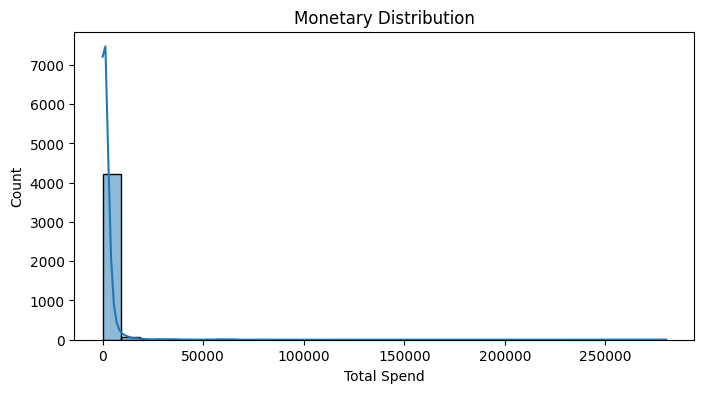

In [512]:
plt.figure(figsize=(8,4))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title("Monetary Distribution")
plt.xlabel("Total Spend")
plt.show()


In [513]:
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

rfm['Monetary'] = np.where(
    rfm['Monetary'] > upper_limit,
    upper_limit,
    rfm['Monetary']
)


# **5.Customer Segmentation**

In [514]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])


In [515]:
from sklearn.cluster import KMeans

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)


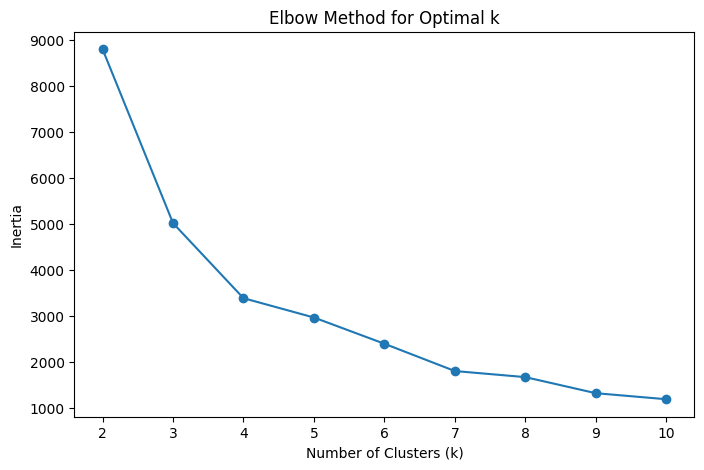

In [516]:
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [517]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores


{2: np.float64(0.41879354625017495),
 3: np.float64(0.528416146339785),
 4: np.float64(0.5358690204021055),
 5: np.float64(0.4448379979470698),
 6: np.float64(0.4359731455605097)}

In [518]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


In [519]:
cluster_profile = (
    rfm.groupby('Cluster')
    .agg({
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': 'mean',
        'CustomerID': 'count'
    })
    .rename(columns={'CustomerID': 'CustomerCount'})
)

cluster_profile


,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,48.854959,2.643388,738.750419,2420
1,251.659491,1.485323,410.124403,1022
2,29.600686,10.197941,3134.607084,874
3,5.772727,77.454545,3691.770000,22


In [520]:
segment_map = {
    0: 'High-Value',
    1: 'Regular',
    2: 'Occasional',
    3: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)


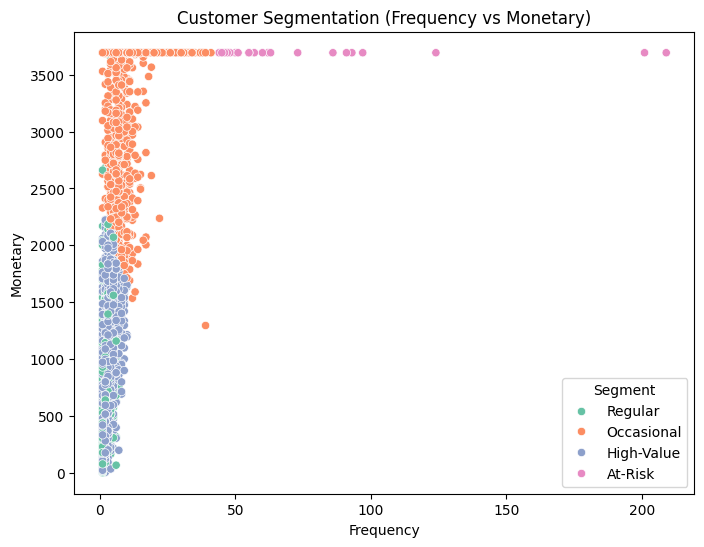

In [521]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Segment'],
    palette='Set2'
)
plt.title("Customer Segmentation (Frequency vs Monetary)")
plt.show()


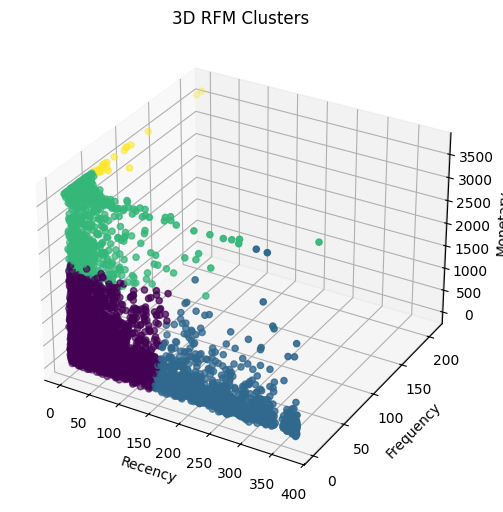

In [522]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis'
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('3D RFM Clusters')

plt.show()


In [523]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,3691.77,1,Regular
1,12347.0,2,7,3691.77,2,Occasional
2,12348.0,75,4,1797.24,0,High-Value
3,12349.0,19,1,1757.55,0,High-Value
4,12350.0,310,1,334.40,1,Regular


# **6.Model Building(Purchase Prediction Model)**

In [524]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [525]:
rfm['Monetary_Log'] = np.log1p(rfm['Monetary'])

In [526]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

rfm['SegmentEncoded'] = le.fit_transform(rfm['Segment'])

In [527]:
# Average Order Value
rfm['AvgOrderValue'] = (
    rfm['Monetary'] / rfm['Frequency']
)

In [528]:
rfm['CustomerValueScore'] = (
    rfm['Frequency'] * rfm['Monetary']
)

In [529]:
rfm['SpendPerPurchase'] = (
    rfm['Monetary'] / (rfm['Frequency'] + 1)
)

In [530]:
rfm['Monetary_Log'] = np.log1p(rfm['Monetary'])

In [531]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

rfm['SegmentEncoded'] = le.fit_transform(rfm['Segment'])

In [532]:
print(rfm.columns.tolist())

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment', 'Monetary_Log', 'SegmentEncoded', 'AvgOrderValue', 'CustomerValueScore', 'SpendPerPurchase']


In [555]:
X = rfm[
    [
        'Recency',
        'Frequency',
        'Cluster',
        'SegmentEncoded'
    ]
]

y = rfm['Monetary_Log']

In [556]:
print(rfm.shape)

print(X.shape)

print(y.shape)

print(rfm.head())

(4338, 11)
(4338, 4)
(4338,)
   CustomerID  Recency  Frequency  Monetary  Cluster     Segment  \
0     12346.0      326          1   3691.77        1     Regular   
1     12347.0        2          7   3691.77        2  Occasional   
2     12348.0       75          4   1797.24        0  High-Value   
3     12349.0       19          1   1757.55        0  High-Value   
4     12350.0      310          1    334.40        1     Regular   

   Monetary_Log  SegmentEncoded  AvgOrderValue  CustomerValueScore  \
0      8.214132               3    3691.770000             3691.77   
1      8.214132               2     527.395714            25842.39   
2      7.494564               1     449.310000             7188.96   
3      7.472245               1    1757.550000             1757.55   
4      5.815324               3     334.400000              334.40   

   SpendPerPurchase  
0        1845.88500  
1         461.47125  
2         359.44800  
3         878.77500  
4         167.20000  


In [557]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

1.Linear Regression

In [558]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [559]:
y_pred

array([ 6.28701385,  5.85009383,  6.39557563,  6.42816042,  6.11712102,
        6.44555368,  5.41932151,  5.709311  ,  6.17002825,  5.87627465,
        7.99322236, 10.11199796,  6.34889051,  6.25186361,  6.37507132,
        7.97821269,  5.81494359,  6.34943612,  5.6858775 ,  5.84991197,
        8.02726211,  7.75523075,  6.34285027,  8.00219179,  7.60291304,
        5.53941817,  7.91651789,  6.35438515,  7.91102326,  6.24307605,
        5.97311968,  6.0909402 ,  6.32820433,  6.21378418,  6.36042539,
        7.82698619,  8.07356422,  6.19986572,  6.38385888,  7.99047504,
        8.01738333,  6.3192349 ,  6.37286962,  5.67123157,  6.31081108,
        5.37245452,  6.41022156,  6.17295743,  6.00241155,  7.87569115,
        5.82958953,  6.35474888,  6.38404075,  6.42193831,  6.44866473,
        5.6214354 ,  6.25497466,  8.01243431,  6.44555368,  6.44866473,
        6.25497466,  6.03803297,  6.31374027,  6.37232401,  7.95275935,
        5.40192826,  6.32545702, 10.19256023,  7.85243952,  6.34

In [560]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 0.766716125078658


In [561]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.5119375393571934


2.Decision Tree Regressor

In [562]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [563]:
dt_pred

array([5.78711139, 6.69016818, 6.25578036, 6.88360927, 3.97029191,
       6.71281297, 4.71312733, 5.7749103 , 6.34852081, 5.25724661,
       7.95014796, 8.21413213, 6.87677976, 5.37440124, 5.99649732,
       8.20019765, 6.1226193 , 6.92475005, 5.24899076, 5.96617238,
       8.21413213, 7.77087727, 4.55597994, 8.10262365, 7.98818662,
       5.18388215, 7.86098335, 5.04405216, 8.19982412, 6.70854818,
       6.53033336, 6.3913642 , 6.43432739, 5.60855593, 6.17629348,
       8.21413213, 8.21413213, 6.57535474, 6.2996093 , 7.50390686,
       8.13319033, 5.51342632, 6.94389433, 6.10359022, 6.49505664,
       4.90537357, 5.91947913, 4.86368088, 6.43590995, 7.68453497,
       6.07670662, 6.17154679, 6.79370489, 6.42868658, 6.97814099,
       4.81347857, 6.49114315, 8.01393869, 6.71281297, 6.97814099,
       6.49114315, 5.87769585, 6.82899969, 6.50361743, 7.83951673,
       5.72629843, 6.51135328, 8.21413213, 8.00151917, 5.2867946 ,
       6.32246235, 8.12870145, 5.71461986, 5.63873826, 6.03072

In [564]:
rmse_dt = np.sqrt(mean_squared_error(y_test, dt_pred))

print("Decision Tree RMSE:", rmse_dt)

Decision Tree RMSE: 0.6818033390961061


In [565]:
r2 = r2_score(y_test, dt_pred)

print("R2 Score:", r2)

R2 Score: 0.6140558534921456


In [566]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest RMSE:", rmse_rf)

r2 = r2_score(y_test, rf_pred)

print("R2 Score:", r2)

Random Forest RMSE: 0.6539909296751889
R2 Score: 0.6449008269279457


In [545]:
import os
os.makedirs("models", exist_ok=True)

In [546]:
import pickle

# Save KMeans model
with open("models/kmeans_rfm.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Save scaler
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


In [547]:
product_customer_matrix = df_clean.pivot_table(
    index='Description',
    columns='CustomerID',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

product_customer_matrix.shape


(3877, 4338)

In [548]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(product_customer_matrix)


In [549]:
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_customer_matrix.index,
    columns=product_customer_matrix.index
)

product_similarity_df.head()


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000228,0.000000,0.000000,0.020228,0.000000,0.000263,0.063543,...,0.0,0.001376,0.015917,0.001771,0.0,0.002852,0.0,0.013155,0.000000,0.002599
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003534,0.004001,0.000000,0.020230,0.027477,0.902593,0.119038,0.013384,...,0.0,0.001726,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003534,1.000000,0.870965,0.980574,0.006358,0.005311,0.003040,0.001764,0.411471,...,0.0,0.000044,0.002869,0.344928,0.0,0.525868,0.0,0.822964,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000228,0.004001,0.870965,1.000000,0.883987,0.020076,0.004912,0.004051,0.008249,0.382226,...,0.0,0.001416,0.004198,0.310053,0.0,0.471772,0.0,0.749303,0.000000,0.010394
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980574,0.883987,1.000000,0.000000,0.000000,0.000000,0.000000,0.410712,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837176,0.000000,0.000000


In [550]:
def recommend_products(product_name, similarity_df, top_n=5):
    if product_name not in similarity_df.index:
        return f"Product '{product_name}' not found."

    similarity_scores = (
        similarity_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    return similarity_scores.index.tolist()


In [551]:
recommend_products(
    product_name=product_similarity_df.index[0],
    similarity_df=product_similarity_df
)


['4 PINK DINNER CANDLE SILVER FLOCK',
 'PINK/FLOWER RABBIT EGG WARMER ',
 '4 BLUE DINNER CANDLES SILVER FLOCK',
 'GREEN WIRE STANDING CANDLE HOLDER',
 '12 IVORY ROSE PEG PLACE SETTINGS']

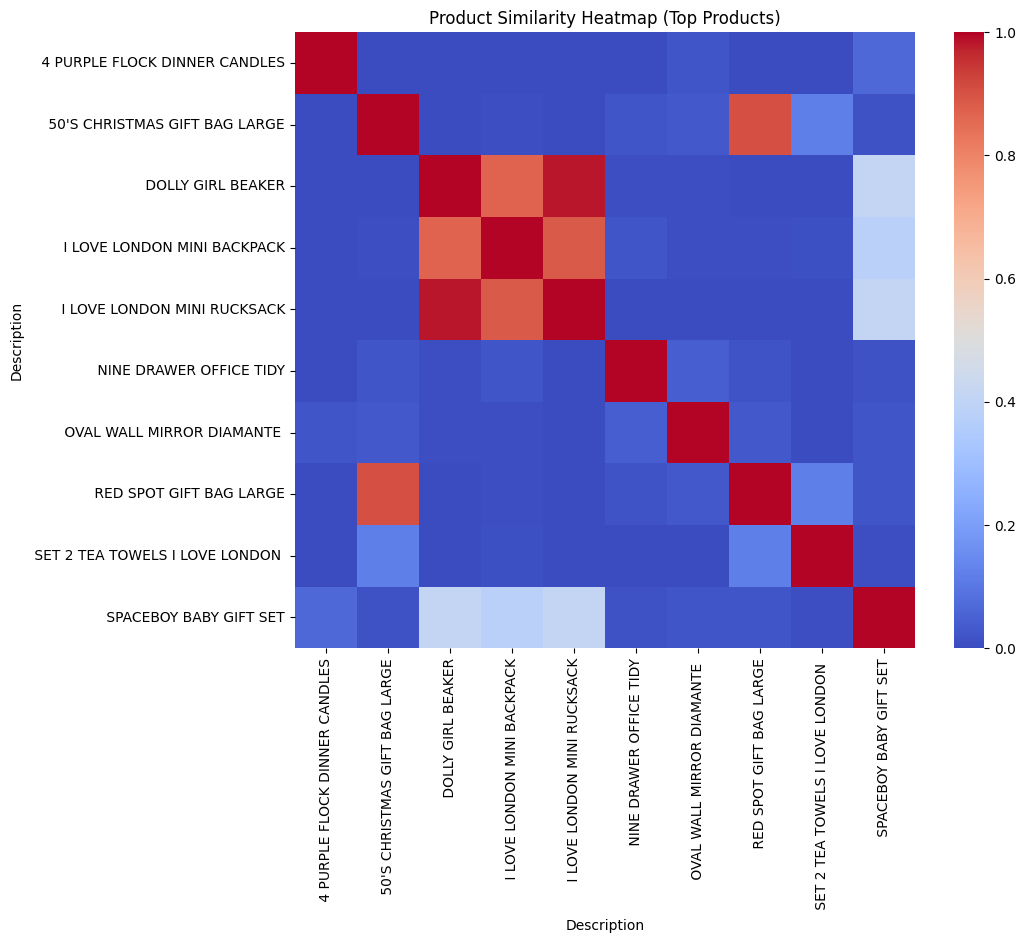

In [552]:
top_products = product_similarity_df.index[:10]

plt.figure(figsize=(10,8))
sns.heatmap(
    product_similarity_df.loc[top_products, top_products],
    cmap='coolwarm'
)
plt.title("Product Similarity Heatmap (Top Products)")
plt.show()


In [553]:
with open("models/product_similarity.pkl", "wb") as f:
    pickle.dump(product_similarity_df, f)

In [554]:
df_clean.to_csv("models/online_retail_cleaned.csv", index=False)
